In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

### Funciones para la lectura y tratamiento de los datos

In [2]:
def delete_unnecessary_columns(df):
    df_nuevo = df[["attack", "timestamps", "neuron_ids"]].copy()
    return df_nuevo
    
def add_dataset_ID_column(df, i):
    df['dataset_ID'] = i
    return df

def add_interval_column(df, long_interval):
    # Definimos los límites de los intervalos
    bins = range(0, 3000 + long_interval, long_interval)  # 0 a 3000 ms en intervalos de long_interval ms
    # Agregamos una nueva columna al DataFrame con las etiquetas de los intervalos
    df.loc[:, 'interval'] = pd.cut(df['timestamps'], bins=bins, labels=False) + 1
    return df

def add_spikes_column(df):
    df = df.groupby(['dataset_ID', 'interval', 'attack']).size().reset_index(name='spikes')
    return df

# Lee todos los datasets, los junta en uno y lo devuelve en forma de pandas dataframe
def lectura_datasets(long_interval, caso):
    if caso == "Ataque":
        # Ruta base del archivo CSV
        base_path = "./data/csv/output_flash_trial_{}_BKG_trial_9{}/spikes.csv"
    else:
        base_path = "./data/csv/output_FLO_quarter_flash_trial_{}_BKG_trial_9{}/spikes.csv"
        
    # DataFrame vacío para almacenar todos los datos
    combined_dataset = pd.DataFrame()
    
    for i in range(10):
        # Genera la ruta completa del archivo CSV para el valor actual de i
        file_path = base_path.format(i, i)
        
        try:
            # Lee el archivo CSV
            spikes = pd.read_csv(file_path, delimiter=";")
            df = delete_unnecessary_columns(spikes)
            df = add_dataset_ID_column(df, i)
            df = add_interval_column(df, long_interval)
            df = add_spikes_column(df)
            # Concatena el dataframe al conjunto de datos consolidado
            combined_dataset = pd.concat([combined_dataset, df], ignore_index=True)
        
        except FileNotFoundError:
            print(f"Archivo no encontrado para i = {i}")

    return combined_dataset

## Elección del tamaño de la ventana temporal

La simulación dura 3000 ms, por lo que la longitud de la ventana temporal tendrá que ser divisor de este número. 

Un tamaño de ventana demasiado pequeño provocaría que no se capturase la tendencia y la estacionalidad de la serie temporal y un tamaño de ventana muy grande no tendría en cuenta los cambios bruscos (ataques) en la serie temporal. Es por esto que decidimos hacer las pruebas con los **tamaños 50, 100 y 200 ms**, los cuales se corresponden con **60, 30 y 15 intervalos**, respectivamente. Además, el ataque se producía en el instante 625 ms, por lo que se llevará a cabo en los intervalos **13, 7 y 4**, respectivamente.

Para tener una primera aproximación de la forma y evolución de la serie temporal, se empieza mostrando las series temporales procedentes de las 10 simulaciones espontáneas con los tamaños de ventana 50, 100 y 200 ms.

In [3]:
# Lectura simulaciones espontáneas
combined_df_normal_50 = lectura_datasets(50, "Espontáneo")
combined_df_normal_100 = lectura_datasets(100, "Espontáneo")
combined_df_normal_200 = lectura_datasets(200, "Espontáneo")

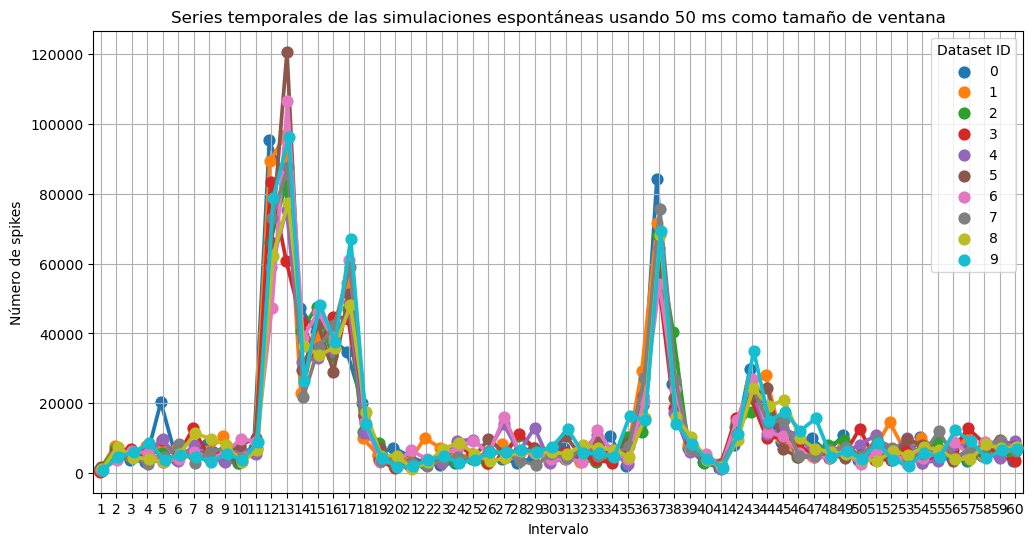

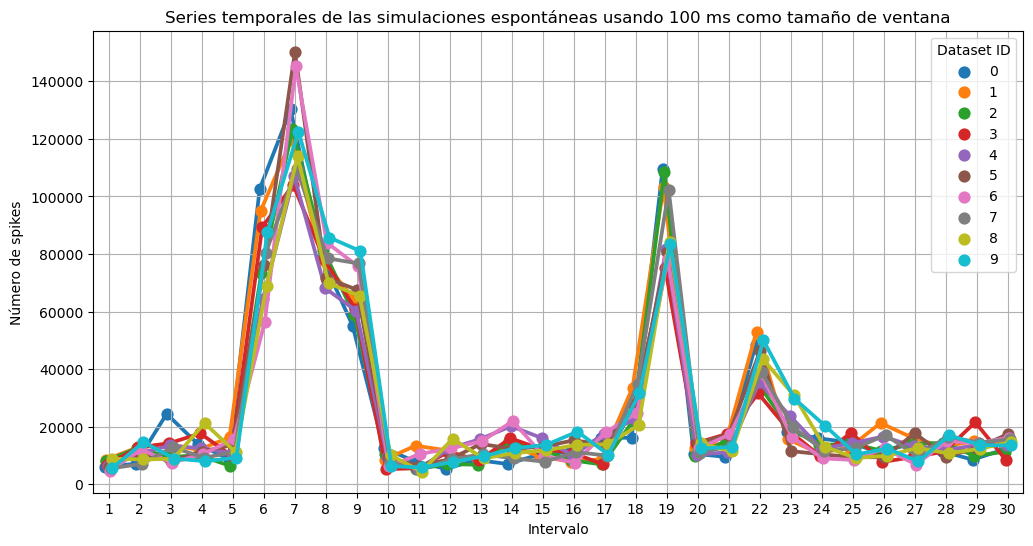

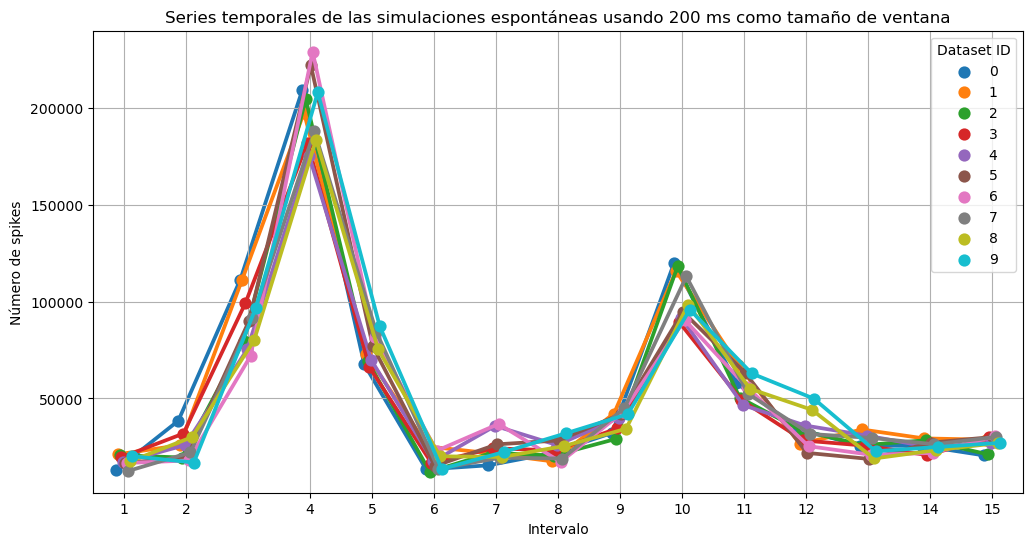

In [4]:
# Gráfico de líneas de las series temporales espontáneas
def plot_spike_series(data, window_size):
    plt.figure(figsize=(12, 6))
    sns.pointplot(data=data, x="interval", y="spikes", hue="dataset_ID", dodge=True)
    
    plt.xlabel("Intervalo")
    plt.ylabel("Número de spikes")
    plt.title(f"Series temporales de las simulaciones espontáneas usando {window_size} ms como tamaño de ventana")
    plt.legend(title="Dataset ID")
    plt.grid(True)
    plt.show()

# Llamadas a la función con diferentes conjuntos de datos
plot_spike_series(combined_df_normal_50, 50)
plot_spike_series(combined_df_normal_100, 100)
plot_spike_series(combined_df_normal_200, 200)

Una primera conclusión que se obtiene al observar la evolución de las series con los distintos tamaños de ventana es que a menor longitud del intervalo tenemos mayor dispersión/variabilidad en el número total de spikes entre los distintos datasets (simulaciones).

### Estudio comparativo: Espontáneo VS Ataque

Por otra parte, se busca que los modelos sean capaces de aprender patrones o relaciones en los datos que puedan diferenciar entre actividad  neuronal espontánea, y actividad neuronal bajo ataque. Por lo tanto, para seleccionar el tamaño de ventana se debe tener en cuenta los dos tipos de simulaciones. Las siguientes pruebas consistirán en un estudio comparativo de las series de los dos tipos de simulaciones. En concreto, se usan las funciones lineplot y boxplot de seaborn.

In [5]:
# Lectura simulaciones ataque
combined_df_ataque_50 = lectura_datasets(50, "Ataque")
combined_df_ataque_100 = lectura_datasets(100, "Ataque")
combined_df_ataque_200 = lectura_datasets(200, "Ataque")

# Unión de los dos tipos de simulaciones en un mismo dataframe para poder hacer el estudio comparativo
combined_df_50 = pd.concat([combined_df_normal_50, combined_df_ataque_50], ignore_index=True)
combined_df_100 = pd.concat([combined_df_normal_100, combined_df_ataque_100], ignore_index=True)
combined_df_200 = pd.concat([combined_df_normal_200, combined_df_ataque_200], ignore_index=True)

/home/sergiolb/anaconda3/envs/Maria/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/sergiolb/anaconda3/envs/Maria/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/sergiolb/anaconda3/envs/Maria/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/sergiolb/anaconda3/envs/Maria/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated

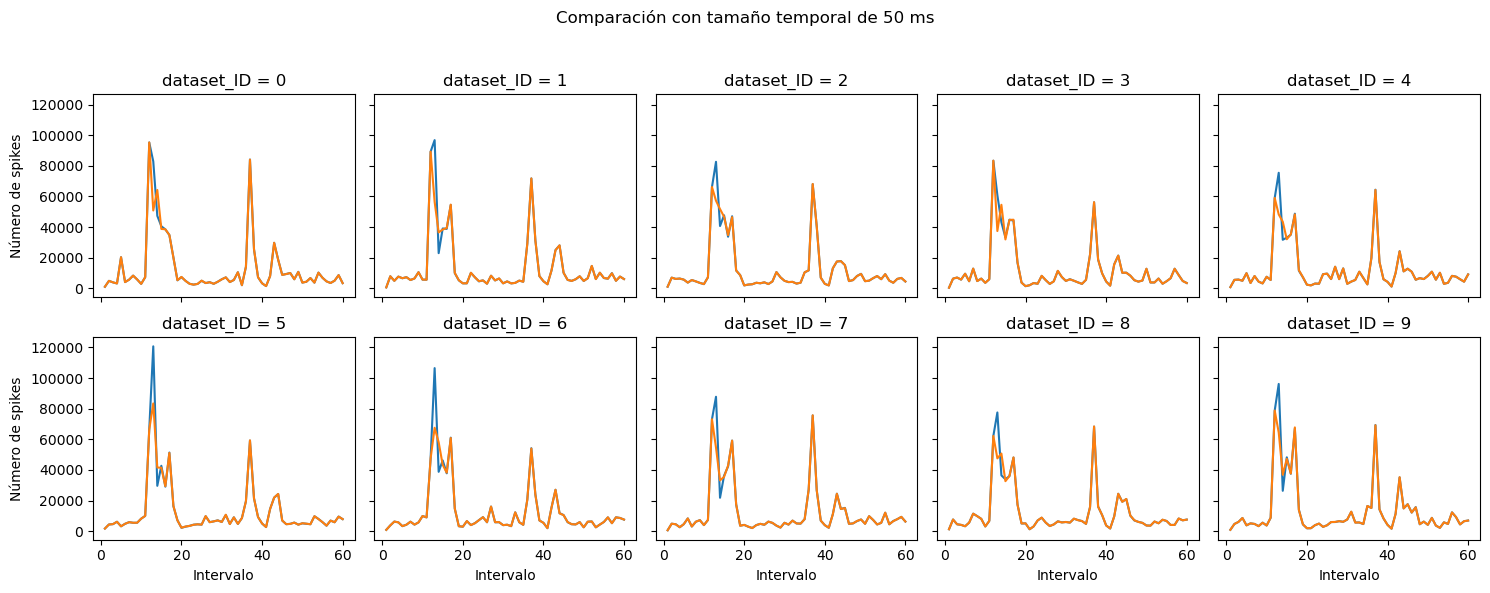

/home/sergiolb/anaconda3/envs/Maria/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/sergiolb/anaconda3/envs/Maria/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/sergiolb/anaconda3/envs/Maria/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/sergiolb/anaconda3/envs/Maria/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated

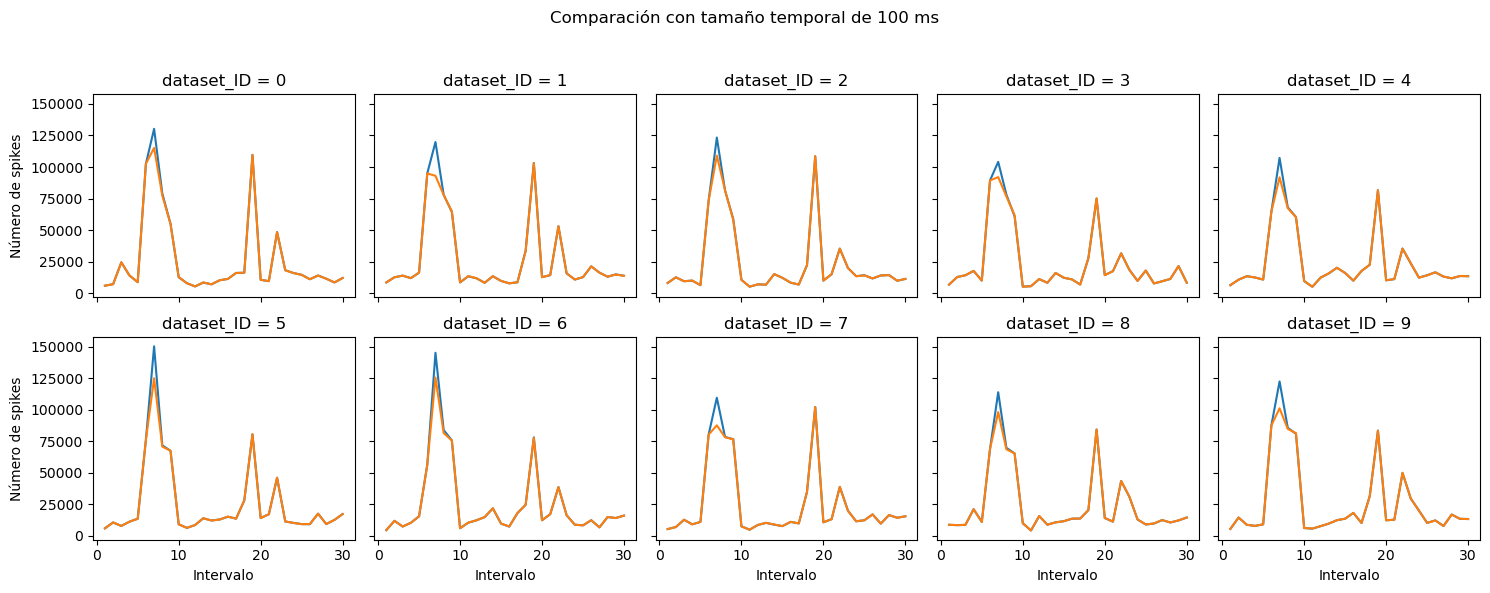

/home/sergiolb/anaconda3/envs/Maria/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/sergiolb/anaconda3/envs/Maria/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/sergiolb/anaconda3/envs/Maria/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/sergiolb/anaconda3/envs/Maria/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated

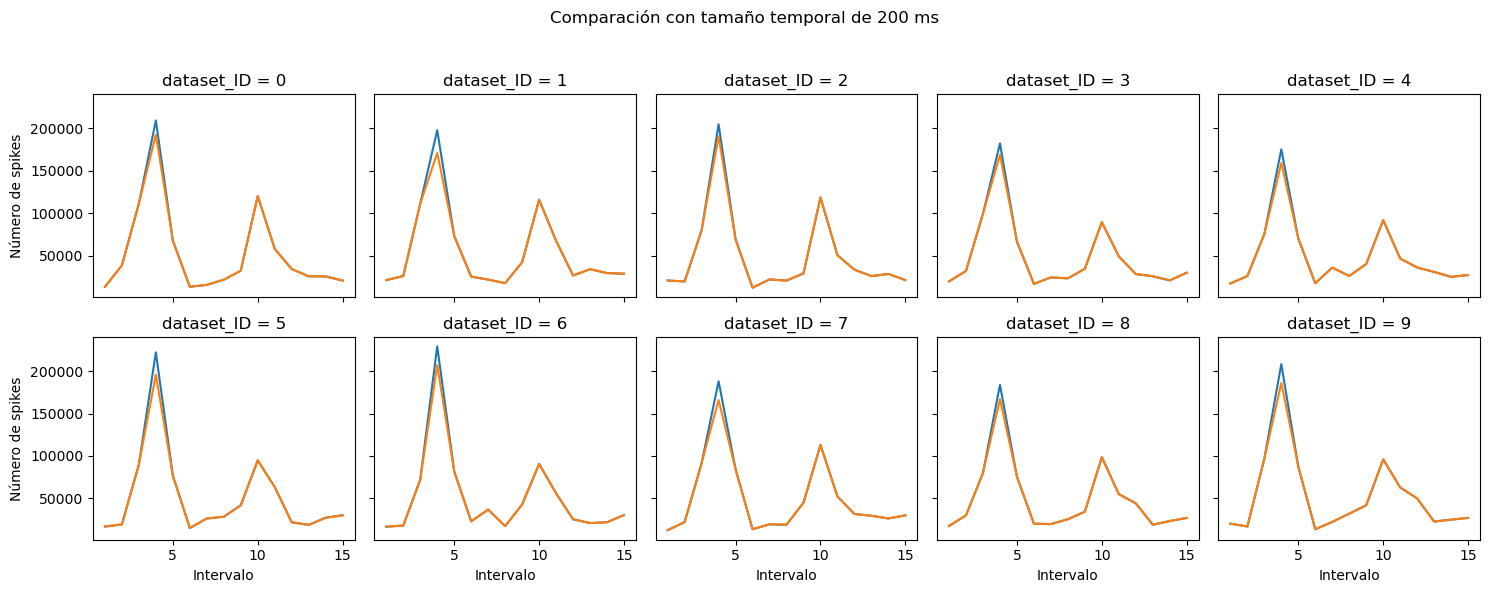

In [6]:
# Serie temporal espontánea VS ataque de las distintas simulaciones
def plot_subplots(data, window_size):
    fig, axes = plt.subplots(2, 5, figsize=(15, 6), sharex=True, sharey=True)
    fig.suptitle(f"Comparación con tamaño temporal de {window_size} ms")
    
    # Obtener los IDs únicos
    dataset_ids = sorted(data['dataset_ID'].unique())
    
    # Generar gráficos individuales por dataset_ID
    for ax, dataset_id in zip(axes.flatten(), dataset_ids):
        subset = data[data['dataset_ID'] == dataset_id]
        
        for attack_type in subset['attack'].unique():
            data_subset = subset[subset['attack'] == attack_type]
            sns.lineplot(x='interval', y='spikes', data=data_subset, ax=ax, label=attack_type)
        
        ax.set_title(f"dataset_ID = {dataset_id}")
        ax.set_xlabel("Intervalo")
        ax.set_ylabel("Número de spikes")
        ax.legend().remove()
    
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

# Llamadas a la función con distintos conjuntos de datos
plot_subplots(combined_df_50, 50)
plot_subplots(combined_df_100, 100)
plot_subplots(combined_df_200, 200)

Se observa que las series son idénticas menos el momento en el que se produce el ataque, es decir, el intervalo número 13 cuando el tamaño de la ventana es de 50 ms, el intervalo número 7 para 100 ms, y el intervalo número 4 para 200 ms. Sin embargo, estos gráficos no ofrecen más información que la de visualizar las series temporales en ambos casos. Se pasa a compararlas con la función boxplot, la cual compara la variabilidad del número de spikes sobre cada intervalo de tiempo tanto en las simulaciones espontáneas como las simulaciones con ataque.

In [7]:
# Boxplot sobre cada uno de los intervalos de ambas simulaciones
def plot_boxplot(data, window_size):
    plt.figure(figsize=(8, 6))
    sns.boxplot(x='interval', y='spikes', hue='attack', data=data)
    
    # Configuración del gráfico
    plt.title(f"Intervalo de {window_size} ms")
    plt.xlabel("Intervalo")
    plt.ylabel("Número de spikes")
    plt.legend(title="attack")
    plt.xticks(rotation=0)
    plt.show()

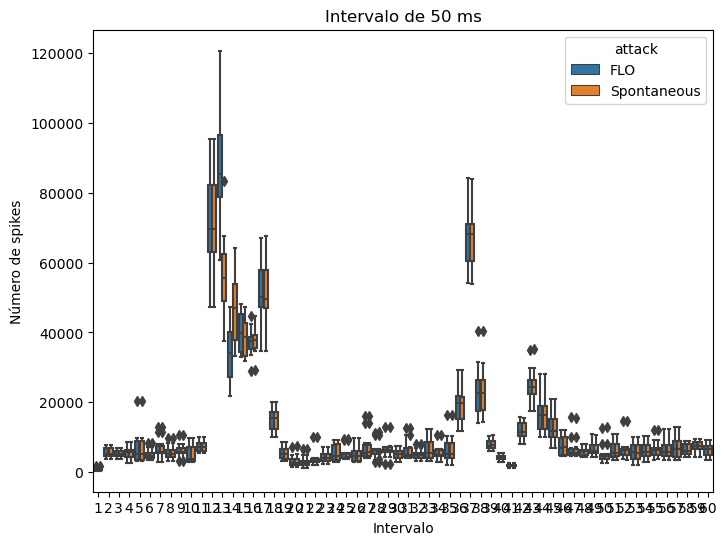

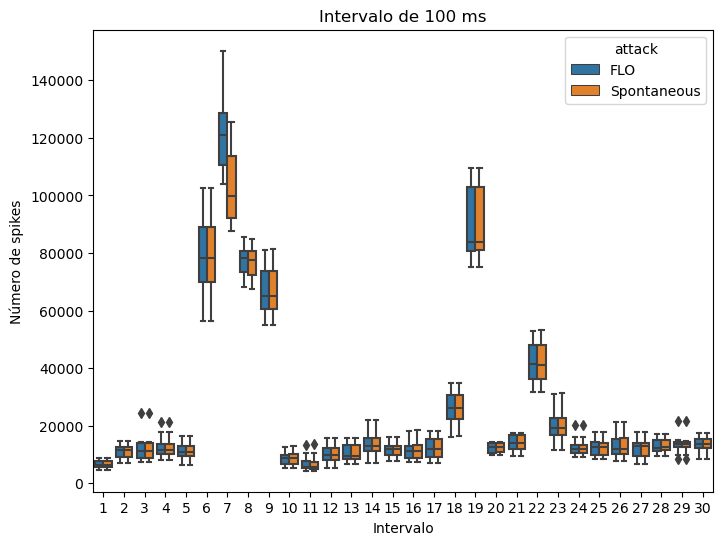

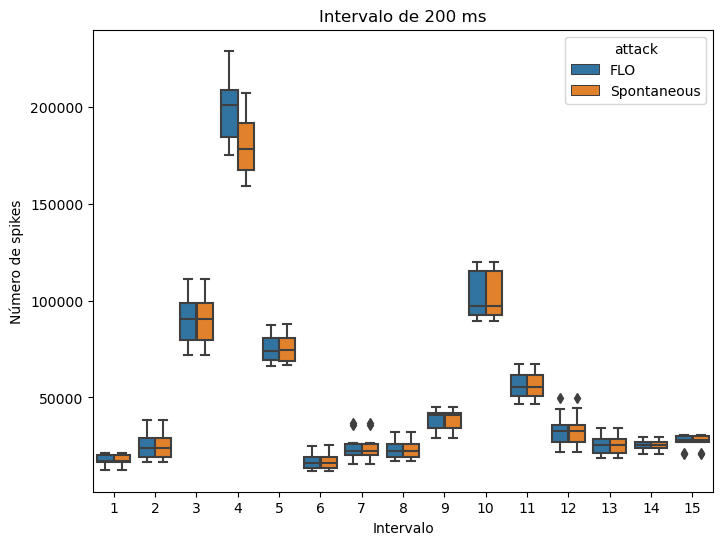

In [8]:
# Llamadas a la función
plot_boxplot(combined_df_50, 50)
plot_boxplot(combined_df_100, 100)
plot_boxplot(combined_df_200, 200)

En cuanto a los boxplots, se observa que con tamaño de ventana 50 ms no solo se muestran diferencias significativas en el momento del ataque (intervalo 13), sino también en los posteriores. Esto podría llevar a que los modelos detecten varios puntos de ataque, en vez de uno. Es por ello y por la alta dispersión previamente comentada que se decide descartar 50 ms como la longitud del intervalo en la serie temporal.

Por el contrario, para los tamaños de ventana 100 ms y 200 ms las diferencias más relevantes se encuentran en el momento del ataque (intervalos 7 y 4, respectivamente). Sin embargo, en este instante de cada uno de los gráficos, las distribuciones de los casos de ataque y espontáneo se diferencian más con 100 ms que con 200 ms. Por lo tanto, la elección del tamaño de ventana para la serie temporal será de 100 ms, lo que corresponde con 30 intervalos por conjunto de datos.